In [2]:
!pip install yfinance

  Obtaining dependency information for yfinance from https://files.pythonhosted.org/packages/1e/60/462859de757ac56830824da7e8cf314b8b0321af5853df867c84cd6c2128/yfinance-1.2.0-py2.py3-none-any.whl.metadata
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Obtaining dependency information for frozendict>=2.3.4 from https://files.pythonhosted.org/packages/38/74/f94141b38a51a553efef7f510fc213894161ae49b88bffd037f8d2a7cb2f/frozendict-2.4.7-py3-none-any.whl.metadata
  Obtaining dependency information for peewee>=3.16.2 from https://files.pythonhosted.org/packages/2d/31/93950b2c7145ea10aa454397ffa308c9aadc98dcb4103b676396571bfadd/peewee-4.0.3-py3-none-any.whl.metadata
  Obtaining dependency information for curl_cffi<0.14,>=0.7 from https://files.pythonhosted.org/packages/6d/e4/15a253f9b4bf8d008c31e176c162d2704a7e0c5e24d35942f759df107b68/curl_cffi-0.13.0-cp39-abi3-win_amd64.whl.metadata
  Obtaining dependency information for websockets>=13.

In [3]:
import sys
!{sys.executable} -m pip install yfinance pandas numpy matplotlib seaborn scikit-learn ta xgboost

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Obtaining dependency information for xgboost from https://files.pythonhosted.org/packages/1f/3d/1661dd114a914a67e3f7ab66fa1382e7599c2a8c340f314ad30a3e2b4d08/xgboost-3.2.0-py3-none-win_amd64.whl.metadata
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.1/101.7 MB 656.4 kB/s eta 0:02:35
   ---------------------------------------- 0.1/101.7 MB 1.1 MB/s eta 0:01:36
   ---------------------------------------- 0.2/101.7 MB 1.3 MB/s eta 0:01:18
   ---------------------------------------- 0.4/101.7 MB 1.6 MB/s eta 0:01:02
   ---------------------------------------- 0.6/101.7 MB 2.1 MB/s eta 0:00:49
   ---------------------------------------- 0.7/101.7 MB 2.4 MB/s eta 0:00:43
   ---------------------------------------- 1.1/101.7 MB 3.1 MB/s eta 0:00:33
   

In [4]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Load Dataset

In [5]:
data = yf.download("RELIANCE.NS", start="2015-01-01", end="2024-01-01")
data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2015-01-01,189.999771,190.877125,189.090320,189.657400,2963643
2015-01-02,189.496948,191.743828,189.229471,190.042616,7331366
2015-01-05,187.421265,190.641790,187.046782,189.379255,10103941
2015-01-06,178.915253,186.811408,178.037899,186.169449,18627980
2015-01-07,182.809830,183.772776,179.107845,179.129243,20720312


In [8]:
#Understand Data

In [9]:
data.info()
data.describe()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2221 entries, 2015-01-01 to 2023-12-29
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   (Close, RELIANCE.NS)   2221 non-null   float64
 1   (High, RELIANCE.NS)    2221 non-null   float64
 2   (Low, RELIANCE.NS)     2221 non-null   float64
 3   (Open, RELIANCE.NS)    2221 non-null   float64
 4   (Volume, RELIANCE.NS)  2221 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 104.1 KB


Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
count,2221.000000,2221.000000,2221.000000,2221.000000,2.221000e+03
mean,654.967930,662.343850,648.140288,655.455241,1.900301e+07
std,370.662888,374.317949,367.263496,370.971811,1.399048e+07
min,173.490646,174.977862,170.430622,174.742482,1.705656e+06
25%,286.076843,290.777035,284.433423,287.314856,1.102748e+07
50%,569.417725,576.243553,564.201701,570.484888,1.498274e+07
75%,1054.023438,1068.658620,1039.196422,1051.960503,2.161084e+07
max,1297.294922,1303.754399,1283.922089,1299.582584,1.426834e+08


In [10]:
#Data Cleaning

In [11]:
data = data.dropna()

In [12]:
#Feature Engineering

In [13]:
# Moving averages
data['SMA_10'] = data['Close'].rolling(10).mean()
data['SMA_50'] = data['Close'].rolling(50).mean()

# Exponential Moving Average
data['EMA_10'] = data['Close'].ewm(span=10).mean()

# Returns
data['Returns'] = data['Close'].pct_change()

# Volatility
data['Volatility'] = data['Returns'].rolling(10).std()

In [14]:
#Add RSI

In [16]:
from ta.momentum import RSIIndicator

# FIX: convert to 1D
close_prices = data['Close'].squeeze()

rsi = RSIIndicator(close=close_prices, window=14)
data['RSI'] = rsi.rsi()

In [17]:
#Drop NaN after feature creation

In [18]:
data = data.dropna()

In [19]:
#Create Target Variable

In [20]:
data['Target'] = data['Close'].shift(-1)
data = data.dropna()

In [21]:
#Define Features & Labels

In [22]:
X = data.drop(['Target'], axis=1)
y = data['Target']

In [23]:
#Train-Test Split

In [24]:
split = int(len(data) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [25]:
#Feature Scaling

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [27]:
#Linear Regression

In [28]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

In [29]:
#Random Forest Regressor

In [30]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [31]:
#XGBoost Regressor

In [32]:
from xgboost import XGBRegressor

xgb = XGBRegressor()
xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

In [33]:
#Model Evaluation

In [34]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    print(f"{name} Performance:")
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("----------------------")

evaluate(y_test, lr_pred, "Linear Regression")
evaluate(y_test, rf_pred, "Random Forest")
evaluate(y_test, xgb_pred, "XGBoost")

Linear Regression Performance:
MAE: 11.688429261704306
RMSE: 15.824688593837687
----------------------
Random Forest Performance:
MAE: 19.28355744460534
RMSE: 26.15132960513844
----------------------
XGBoost Performance:
MAE: 24.965042009024785
RMSE: 32.905033368692465
----------------------


In [35]:
#Visualization

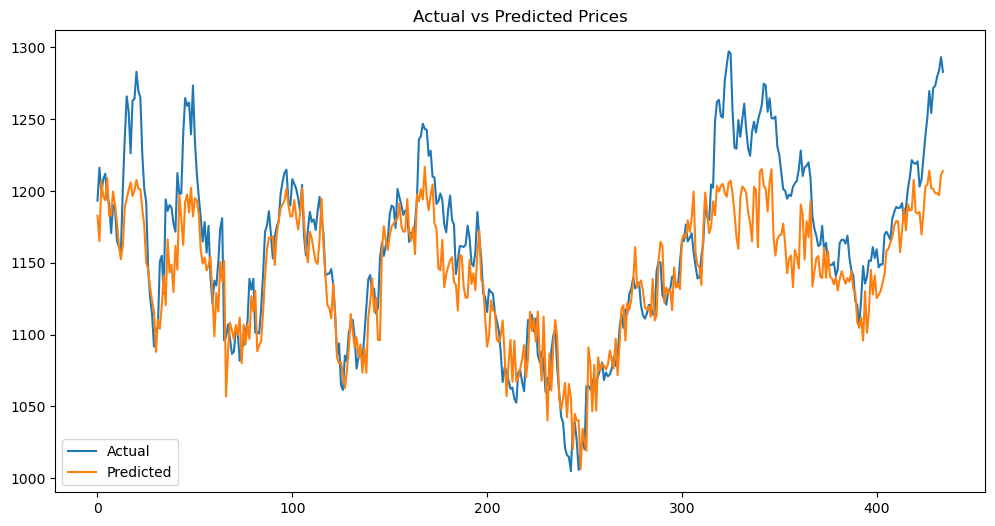

In [36]:
plt.figure(figsize=(12,6))
plt.plot(y_test.values, label="Actual")
plt.plot(xgb_pred, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Prices")
plt.show()

In [37]:
#Model Comparison Table

In [38]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XGBoost"],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred)),
        np.sqrt(mean_squared_error(y_test, xgb_pred))
    ]
})

results

,Model,RMSE
0,Linear Regression,15.824689
1,Random Forest,26.151330
2,XGBoost,32.905033


In [39]:
#Save Best Model

In [40]:
import pickle

pickle.dump(xgb, open("price_model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))